# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 6





Z [Wikipedii](https://pl.wikipedia.org/wiki/Paradoks_Monty%E2%80%99ego_Halla):

> Zawodnik stoi przed trzema zasłoniętymi bramkami. Za jedną z nich (za którą – wie to tylko prowadzący program) jest nagroda (umieszczana całkowicie losowo). Gracz wybiera jedną z bramek. Prowadzący program odsłania inną bramkę (co istotne – anonsując, że jest to bramka pusta), po czym proponuje graczowi zmianę wyboru. <br /><br />
Intuicyjnie nie ma znaczenia, czy zawodnik pozostanie przy swoim wyborze, czy nie. Okazuje się jednak, że jest inaczej. Przy wyborze strategii pozostawania przy swoim pierwszym wyborze prawdopodobieństwo wygranej wynosi 1/3. Natomiast przy wyborze „strategii zmiany” wynosi 2/3. <br /><br />
Oznacza to, że zawodnikowi opłaci się zmienić bramkę, ponieważ ma wtedy dwa razy większe szanse na wygraną. Paradoks wynika z niedocenienia informacji, jaką „między wierszami” przekazuje prowadzący. Informacją tą jest wskazanie pustej bramki. <br /><br />
Innymi słowy poprzez otwarcie jednej z pustych bramek prowadzący zmniejsza liczność zbioru „pustych bramek”, a w rezultacie prawdopodobieństwo przegranej z 2/3 do 1/3. „Pozostałe” prawdopodobieństwo wygranej musi wynosić więc obecnie 2/3.

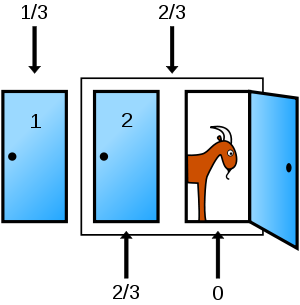






Zaimplementuj symulację paradoksu Monty'ego Halla. Przeprowadź eksperyment losowy, w którym gra zostanie rozegrana określoną liczbę razy (liczbę rozgrywek należy ustawić jako parametr programu).

### Zadanie 1

Symulację należy przeprowadzić w dwóch wariantach:

1. Gracz zawsze zostaje przy pierwotnie wybranej bramce.
2. Gracz zawsze zmienia swój wybór po tym, jak prowadzący ujawni jedną z bramek bez nagrody.

Po zakończeniu symulacji porównaj skuteczność obu strategii.

Odpowiedz na pytanie: **Czy uzyskane wyniki są zgodne z teorią paradoksu Monty'ego Halla?**





In [1]:
import random
import matplotlib.pyplot as plt
import pandas as pd

In [40]:
number_of_games = 10000

initial_guesses = 0
always_change = 0

for _ in range(number_of_games):
    car = random.randint(0,2)
    guess = random.randint(0,2)
    
    # always stays
    if car == guess:
        initial_guesses += 1
    
    # always change
    left_choices = set(range(3)) - {guess, car} # gates that are not the car or the guess
    left_choices_minus_empty = set(range(3)) - set([random.choice(list(left_choices))] + [guess]) # gates that are not the car or the guess and not the empty gate
    guess = int(random.choice(list(left_choices_minus_empty))) # guess the other gate
    if guess == car:
        always_change += 1

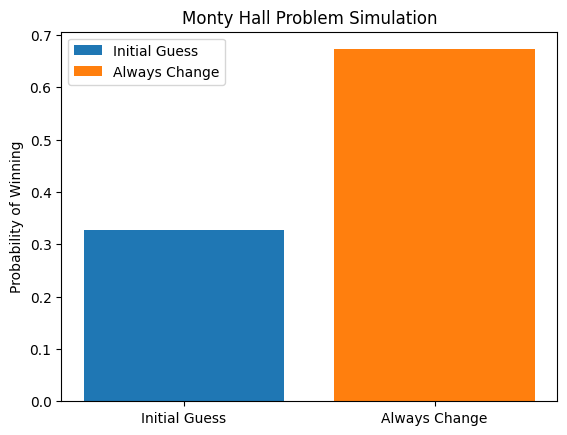

In [41]:
plt.bar(0, [initial_guesses/number_of_games], label="Initial Guess")
plt.bar(1, [always_change/number_of_games], label="Always Change")
plt.xticks([0, 1], ["Initial Guess", "Always Change"])
plt.ylabel("Probability of Winning")
plt.title("Monty Hall Problem Simulation")
plt.legend()
plt.show()

#### Zadanie 2

Napisz program, który umożliwia przeprowadzenie symulacji paradoksu Monty'ego Halla z dowolną liczbą bramek (możliwość podania tej liczby jako parametr).

Zasady symulacji:

* Gracz losowo wybiera jedną z $N$ bramek.
* Prowadzący odsłania jedną z pozostałych $N - 1$ bramek, za którą na pewno nie ma nagrody.
* Gracz następnie losowo wybiera jedną z pozostałych $N - 2$ bramek (innych niż pierwotny wybór oraz bramka odsłonięta przez prowadzącego).

W przypadku $N = 100$ gracz wybiera jedną ze 100 bramek, prowadzący odsłania jedną (w której nie ma nagrody) z 99 pozostałych, a następnie gracz wybiera losowo jedną z 98 bramek.

Na koniec porównaj skuteczność strategii "pozostania przy wyborze" oraz "zmiany wyboru" (losowej zmiany wśród dostępnych opcji).



In [50]:
def monty_hall(num_of_games, num_of_gates):
    initial_guesses = 0
    always_change = 0
    
    for _ in range(num_of_games):
        car = random.randint(0, num_of_gates - 1)
        guess = random.randint(0, num_of_gates - 1)
        
        # always stays
        if car == guess:
            initial_guesses += 1
        
        # always change
        left_choices = set(range(num_of_gates)) - {car, guess} 
        left_choices_minus_empty = set(range(num_of_gates)) - set([random.choice(list(left_choices))] + [guess])
        guess = int(random.choice(list(left_choices_minus_empty)))
        if guess == car:
            always_change += 1
            
    return initial_guesses, always_change

In [57]:
num_of_gates = 4
initial_guesses, always_change = monty_hall(10000, num_of_gates)

[0.2541, 0.3732]


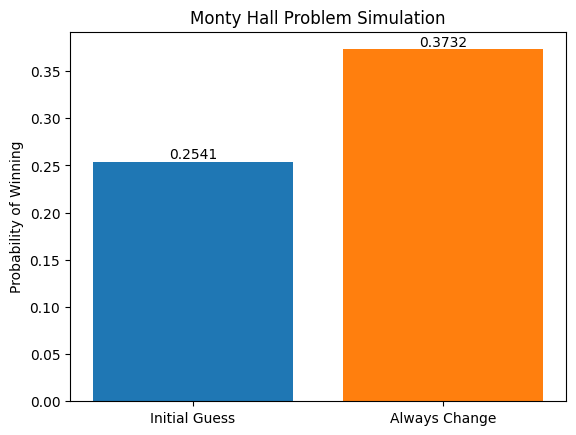

In [58]:
fig, ax = plt.subplots()
probs = [initial_guesses/number_of_games,
         always_change/number_of_games]
labels = ["Initial Guess", "Always Change"]
print(probs)

bars = ax.bar(labels, probs, color=['C0','C1'])
# adds “xx.xx%” on top of each bar
ax.bar_label(bars)

ax.set_ylabel("Probability of Winning")
ax.set_title("Monty Hall Problem Simulation")
plt.show()

#### Zadanie 3

Przeanalizuj, jak liczba bramek wpływa na prawdopodobieństwo wygranej w każdej ze strategii. Wyświetl wykres przedstawiający prawdopodobieństwo wygranej w zależności od liczby bramek dla obu strategii (jako dwie serie danych).

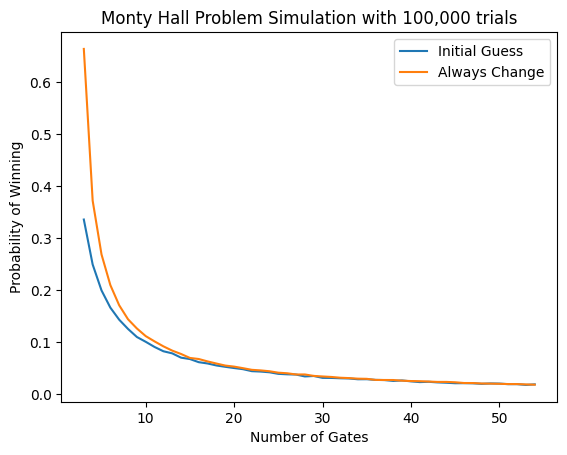

In [62]:
all_probs = []
trials = 100_000
for i in range(3, 55):
    initial_guesses, always_change = monty_hall(trials, i)
    all_probs.append((initial_guesses/trials, always_change/trials))

plt.plot(range(3, 55), [x[0] for x in all_probs], label="Initial Guess")
plt.plot(range(3, 55), [x[1] for x in all_probs], label="Always Change")
plt.xlabel("Number of Gates")
plt.ylabel("Probability of Winning")
plt.title(f"Monty Hall Problem Simulation with {trials:,} trials")
plt.legend()
plt.show()